In [8]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from math import sqrt

In [9]:
df=pd.read_excel("../data/final/delivery_analysis.xlsx")

In [10]:
df.columns

Index(['order_id', 'order_date', 'first_class', 'order_day_name',
       'on_truck_scan_date', 'on_truck_scan_day_name',
       'order_to_truck_scan_days', 'ready_to_ship_date', 'pickup_date',
       'processing_time', 'waiting_time_ready_to_pickup',
       'estimate_delivery_date', 'estimate_shipping_time',
       'estimate_total_order_time', 'real_arrival_date', 'real_whole_process',
       'estimation_error'],
      dtype='object')

In [12]:
df = df.copy()

# 🎯 Total delivery time
df['total_delivery_time'] = (
    df['real_arrival_date'] - df['order_date']
).dt.days

# 🏭 Processing (warehouse)
df['processing_time_clean'] = (
    df['ready_to_ship_date'] - df['order_date']
).dt.days

# ⏳ Waiting before pickup
df['waiting_time_clean'] = (
    df['pickup_date'] - df['ready_to_ship_date']
).dt.days

# 🚚 Shipping time
df['shipping_time_clean'] = (
    df['real_arrival_date'] - df['on_truck_scan_date']
).dt.days

In [13]:
avg_total = df['total_delivery_time'].mean()
median_total = df['total_delivery_time'].median()
on_time = (df['total_delivery_time'] <= 3).mean() * 100

print(f"Avg Delivery: {avg_total:.2f} days")
print(f"Median: {median_total}")
print(f"On-time rate: {on_time:.1f}%")

Avg Delivery: 11.02 days
Median: 12.0
On-time rate: 0.0%


Text(0.5, 1.0, 'Total Delivery Time Distribution')

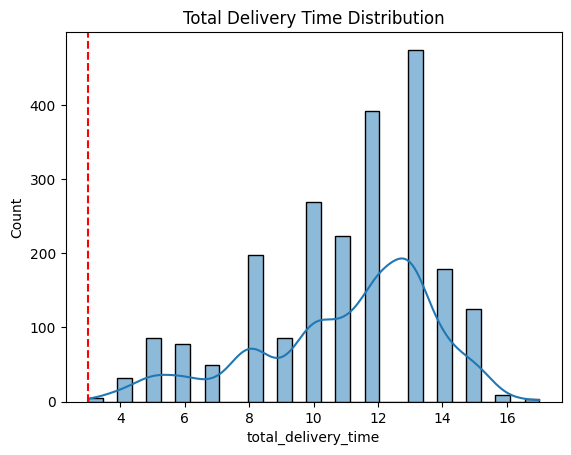

In [14]:
sns.histplot(df['total_delivery_time'], kde=True)
plt.axvline(3, color='red', linestyle='--')
plt.title("Total Delivery Time Distribution")

Text(0, 0.5, 'Days')

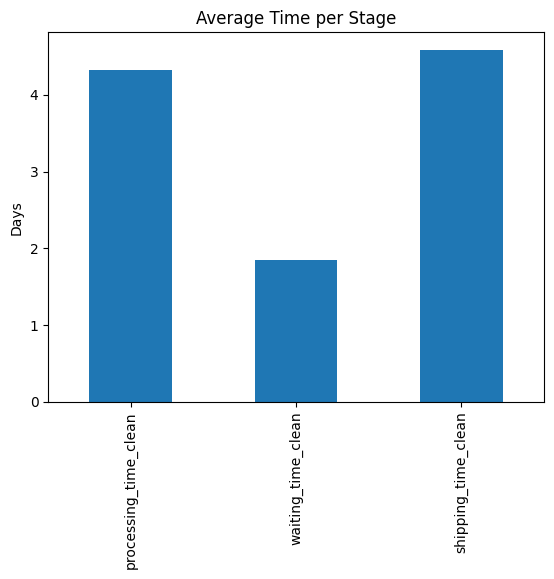

In [15]:
stage_avg = df[
    ['processing_time_clean', 'waiting_time_clean', 'shipping_time_clean']
].mean()

stage_avg.plot(kind='bar')
plt.title("Average Time per Stage")
plt.ylabel("Days")

Text(0.5, 1.0, 'Variability per Stage')

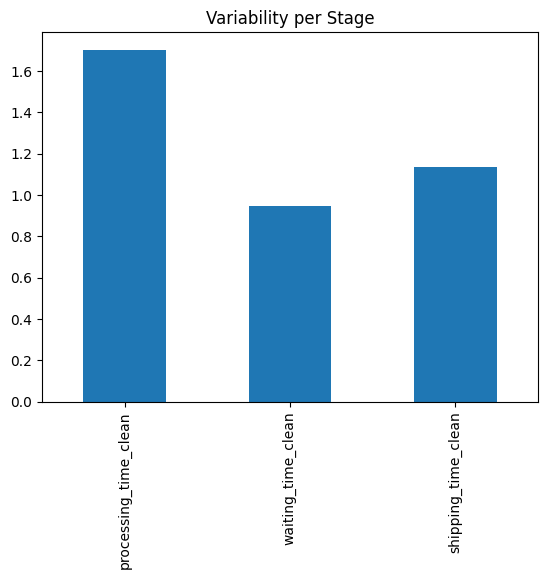

In [16]:
stage_std = df[
    ['processing_time_clean', 'waiting_time_clean', 'shipping_time_clean']
].std()

stage_std.plot(kind='bar')
plt.title("Variability per Stage")

<Axes: >

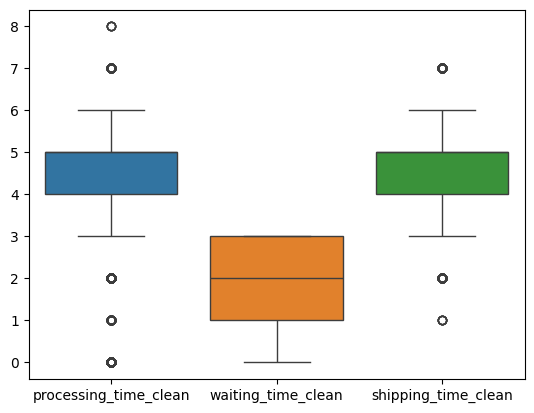

In [17]:
sns.boxplot(data=df[
    ['processing_time_clean', 'waiting_time_clean', 'shipping_time_clean']
])

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'Wednesday'),
  Text(1, 0, 'Monday'),
  Text(2, 0, 'Thursday'),
  Text(3, 0, 'Saturday'),
  Text(4, 0, 'Tuesday'),
  Text(5, 0, 'Friday'),
  Text(6, 0, 'Sunday')])

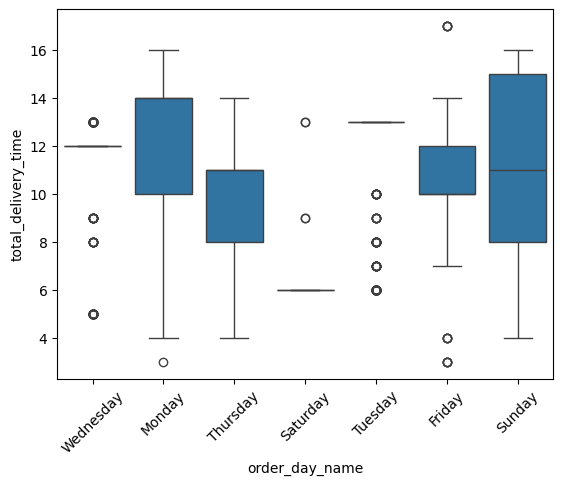

In [18]:
sns.boxplot(
    x='order_day_name',
    y='total_delivery_time',
    data=df
)
plt.xticks(rotation=45)

Text(0.5, 1.0, 'On-Time Delivery Rate')

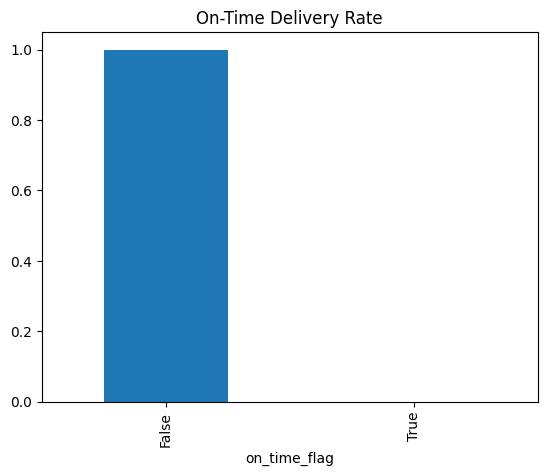

In [19]:
df['on_time_flag'] = df['total_delivery_time'] <= 3

df['on_time_flag'].value_counts(normalize=True).plot(kind='bar')
plt.title("On-Time Delivery Rate")

Text(0.5, 1.0, 'Estimation Error Distribution')

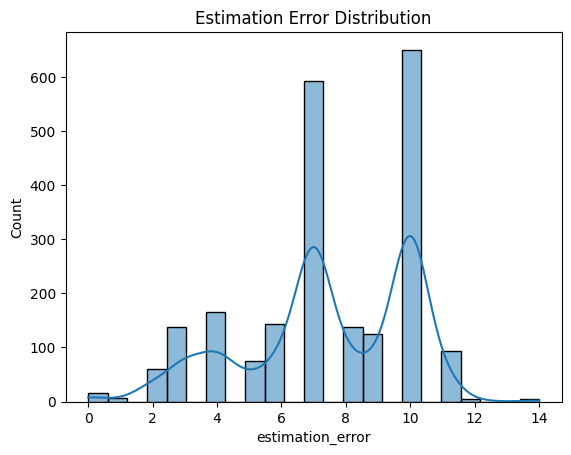

In [20]:
sns.histplot(df['estimation_error'], kde=True)
plt.title("Estimation Error Distribution")

## 📊 Key Findings

- Avg delivery time: X days (target: 3)
- Only X% on time
- Main delay: ______
- Most unstable stage: ______

## 💡 Recommendations

- Increase pickup frequency → reduces waiting_time_clean
- Improve warehouse processing → reduces processing_time_clean